# In-silico variant screening of CRISPR-validated KLF1 enhancers

[KLF1](https://www.ncbi.nlm.nih.gov/gene/10661) (Krüppel-like factor 1)
is the canonical K562 erythroid master regulator. The
[EPCrispr Benchmark](https://www.engreitzlab.org/resources/) catalogues
CRISPR-perturbation results across multiple labs; after filtering to
KLF1 we have **82 candidate CREs on chr19** spanning ±~1.6 Mb around the
TSS at chr19:12,887,180. **Three of those are CRISPR-confirmed
as gene-regulatory** (`Regulated=TRUE`):

| element (1-based hg38) | distance-to-TSS | CRISPR effect | H3K27ac.RPM |
|---|---|---|---|
| chr19:12,888,891–12,889,391 | ~2 kb | −0.169 | 1.71 |
| chr19:12,867,151–12,867,931 | ~20 kb | −0.026 | 2.82 |
| chr19:12,847,511–12,848,011 | ~39 kb | −0.058 | 0.32 |

Rather than benchmark whether the model can rank the 3 validated CREs
against the 79 non-significant ones (n=3 positives makes that very
noisy), this notebook asks a more useful question: **inside each
validated enhancer, which single-base changes does the model predict
would disrupt its activity?** That gives a per-enhancer ranked list of
candidate causal SNVs — i.e. "if you wanted to break this enhancer,
where would you mutate?"

The screen is exhaustive **in-silico saturation mutagenesis** (ISM):
every position of each enhancer's 256-bp window × every alt base. The
cell-specific contrast (K562 minus HepG2) tells us which mutations are
erythroid-specific, narrowing the candidate list to changes likely to
disrupt the K562-relevant TF footprints.

**Runtime**: ~1 min on Apple Silicon (MPS) / NVIDIA (CUDA) —
3 enhancers × 256 positions × 3 alts × 2 cells = 4,608 forward passes
batched into one subprocess.
**Prereqs**: `chorus setup --oracle epinformerseq` + background CDFs at
`~/.chorus/backgrounds/epinformerseq_pertrack.npz`.


## Setup

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import warnings
warnings.filterwarnings('ignore', message=".*padding='same'.*")

import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

import chorus
from chorus.utils import get_genome, extract_sequence
from chorus.oracles.epinformerseq_source.epinformerseq_globals import (
    EPINFORMERSEQ_AVAILABLE_CELLTYPES,
)

ASSAY = 'Enhancer_H3K27ac_DNase'
print('chorus version:', chorus.__version__)
print('assay        :', ASSAY)


chorus version: 0.4.0
assay        : Enhancer_H3K27ac_DNase


In [2]:
genome_path = get_genome('hg38')
print('genome:', genome_path)


genome: /Users/jieconglin/Documents/hpc-projects/chorus/genomes/hg38.fa


## 1. Load the EPCrispr benchmark, filter to KLF1


In [3]:
# Path is relative to the notebook directory (examples/notebooks/).
DATA = '../walkthroughs/CRISPR_valid_CREs/EPCrisprBenchmark_combined_data.training_K562.GRCh38.tsv.gz'
KLF1_TSS = 12887180

df = pd.read_csv(DATA, sep='\t')
klf1 = df[df['measuredGeneSymbol'] == 'KLF1'].copy()
klf1['midpoint'] = (klf1['chromStart'] + klf1['chromEnd']) // 2

reg = klf1[klf1['Regulated'] == True].copy()
reg['distance_kb'] = reg['distanceToTSS'].abs() / 1000

print(f'KLF1 candidate CREs : {len(klf1)}')
print(f'Regulated (TRUE)    : {len(reg)}  <- the three we will screen')

reg[['chrom', 'chromStart', 'chromEnd', 'midpoint',
     'EffectSize', 'distance_kb', 'H3K27ac.RPM',
     'DHS.percentile', 'Dataset']].sort_values('distance_kb')


KLF1 candidate CREs : 82
Regulated (TRUE)    : 3  <- the three we will screen


,chrom,chromStart,chromEnd,midpoint,EffectSize,distance_kb,H3K27ac.RPM,DHS.percentile,Dataset
4610,chr19,12888891,12889391,12889141,-0.169294,1.937,1.707113,0.158131,Nasser2021
4607,chr19,12867151,12867931,12867541,-0.026087,19.661,2.818881,0.952548,Nasser2021
4606,chr19,12847511,12848011,12847761,-0.057784,39.441,0.317648,0.935551,Nasser2021


## 2. Locus map — where the 3 validated enhancers sit

The grey dots are the other 79 tested-but-not-significant CREs;
red dots are the 3 CRISPR-confirmed regulatory enhancers we'll screen.


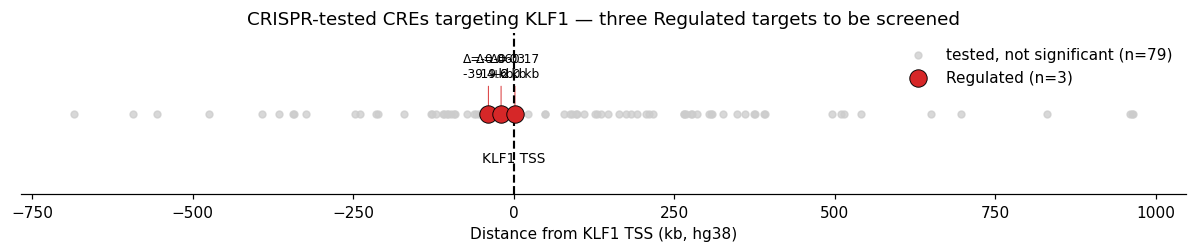

In [4]:
fig, ax = plt.subplots(figsize=(11, 2.4))
neg = klf1[~klf1['Regulated']]
pos = klf1[klf1['Regulated']]

ax.scatter((neg['midpoint'] - KLF1_TSS) / 1e3, np.zeros(len(neg)),
           c='#cccccc', s=20, alpha=0.75,
           label=f'tested, not significant (n={len(neg)})', zorder=2)
ax.scatter((pos['midpoint'] - KLF1_TSS) / 1e3, np.zeros(len(pos)),
           c='#d62728', s=130, edgecolor='black', linewidth=0.6,
           label=f'Regulated (n={len(pos)})', zorder=4)

for _, row in pos.iterrows():
    dx_kb = (row['midpoint'] - KLF1_TSS) / 1e3
    ax.annotate(
        f"Δ={row['EffectSize']:+.2f}\n{dx_kb:+.1f} kb",
        xy=(dx_kb, 0), xytext=(0, 22), textcoords='offset points',
        ha='center', va='bottom', fontsize=8,
        arrowprops={'arrowstyle': '-', 'color': '#d62728', 'lw': 0.6},
    )

ax.axvline(0, color='black', lw=1.4, ls='--', zorder=3)
ax.text(0, -0.7, 'KLF1 TSS', ha='center', va='top', fontsize=9)
ax.set_xlabel('Distance from KLF1 TSS (kb, hg38)')
ax.set_yticks([])
ax.set_ylim(-1.5, 1.5)
ax.set_title('CRISPR-tested CREs targeting KLF1 — three Regulated targets to be screened')
ax.legend(loc='upper right', frameon=False)
ax.spines['left'].set_visible(False)
plt.tight_layout(); plt.show()


## 3. Extract 256-bp midpoint windows for the 3 enhancers

EPInformer-seq scores fixed 256-bp windows. For each Regulated CRE we
take the central 256 bp around the element's midpoint (the CREs are
500–780 bp wide, so this captures the core of each).


In [5]:
def make_enhancer_record(row):
    mid = int(row['midpoint'])
    start = mid - 128 + 1   # 1-based inclusive
    end   = mid + 128
    seq = extract_sequence(f'chr19:{start}-{end}', str(genome_path)).upper()
    assert len(seq) == 256 and 'N' not in seq, \
        f'unexpected window: chr19:{start}-{end}, len={len(seq)}'
    label = f'{row["chrom"]}:{int(row["chromStart"]):,}-{int(row["chromEnd"]):,}'
    return {
        'label':         label,
        'distance_kb':   float(abs(row['distanceToTSS']) / 1000),
        'effect_crispr': float(row['EffectSize']),
        'crispr_start':  int(row['chromStart']),
        'crispr_end':    int(row['chromEnd']),
        'window_start':  start,
        'window_end':    end,
        'midpoint':      mid,
        'sequence':      seq,
        'h3k27ac_rpm':   float(row['H3K27ac.RPM']),
    }

enhancer_rows = (reg.sort_values('distanceToTSS', key=lambda s: s.abs())
                    .apply(make_enhancer_record, axis=1, result_type='expand'))
enhancers = enhancer_rows.reset_index(drop=True)
enhancers[['label', 'distance_kb', 'effect_crispr',
           'window_start', 'window_end', 'h3k27ac_rpm']]


,label,distance_kb,effect_crispr,window_start,window_end,h3k27ac_rpm
0,"chr19:12,888,891-12,889,391",1.937,-0.169294,12889014,12889269,1.707113
1,"chr19:12,867,151-12,867,931",19.661,-0.026087,12867414,12867669,2.818881
2,"chr19:12,847,511-12,848,011",39.441,-0.057784,12847634,12847889,0.317648


## 4. Score the wild-type windows in K562 + HepG2

A quick sanity check that the model picks up real activity at all three
of these CRISPR-validated enhancers before we look at variant effects.


In [6]:
oracle = chorus.create_oracle(
    'epinformerseq',
    use_environment=True,
    cell_type='K562',
    reference_fasta=str(genome_path),
)
oracle.load_pretrained_model()
print('oracle loaded, assay_id =', oracle.assay_id)


2026-05-11 17:08:09,452 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-11 17:08:10,663 - chorus.core.base - INFO - Using conda environment: chorus-epinformerseq


2026-05-11 17:08:13,645 - chorus.oracles.epinformerseq - INFO - EPInformer-seq model loaded successfully in environment.


oracle loaded, assay_id = Enhancer_H3K27ac_DNase:K562


In [7]:
sequences = enhancers['sequence'].tolist()
labels    = enhancers['label'].tolist()
weights_k562  = str(oracle.get_model_weights_dir().parent / 'K562' / 'weights.pt')
weights_hepg2 = str(oracle.get_model_weights_dir().parent / 'HepG2' / 'weights.pt')

wt_script = f'''
import torch
from chorus.oracles.epinformerseq_source.model_usage import load_model, predict_activity

device_str = (
    'cuda' if torch.cuda.is_available()
    else ('mps' if getattr(torch.backends, "mps", None) is not None
                   and torch.backends.mps.is_available()
          else 'cpu')
)
device = torch.device(device_str)

sequences = {sequences!r}

def score_all(weights_path):
    model = load_model(weights_path, device=device)
    return [float(predict_activity(model, seq=s, average_reverse=False, device=device)[0][0])
            for s in sequences]

result = {{
    'K562':  score_all({weights_k562!r}),
    'HepG2': score_all({weights_hepg2!r}),
    'device': device_str,
}}
'''

t0 = time.time()
wt = oracle.run_code_in_environment(wt_script, timeout=300)
print(f'WT scored in {time.time()-t0:.1f} s on {wt["device"]}')

enhancers['wt_K562']  = wt['K562']
enhancers['wt_HepG2'] = wt['HepG2']
enhancers[['label', 'distance_kb', 'h3k27ac_rpm', 'wt_K562', 'wt_HepG2']]


WT scored in 3.2 s on mps


,label,distance_kb,h3k27ac_rpm,wt_K562,wt_HepG2
0,"chr19:12,888,891-12,889,391",1.937,1.707113,0.407618,0.404768
1,"chr19:12,867,151-12,867,931",19.661,2.818881,0.881019,0.821194
2,"chr19:12,847,511-12,848,011",39.441,0.317648,2.163162,1.592156


## 5. Saturation mutagenesis across all 3 enhancers in K562 + HepG2

3 enhancers × 256 positions × 3 alt bases × 2 cells = **4,608 forward
passes**. We batch all of it into one `run_code_in_environment` call:
each cell type's weights load once, then we score all 3 enhancers'
mutation grids in-process.


In [8]:
ism_script = f'''
import torch
from chorus.oracles.epinformerseq_source.model_usage import load_model, predict_activity

device_str = (
    'cuda' if torch.cuda.is_available()
    else ('mps' if getattr(torch.backends, "mps", None) is not None
                   and torch.backends.mps.is_available()
          else 'cpu')
)
device = torch.device(device_str)

sequences = {sequences!r}
bases = ['A', 'C', 'G', 'T']

def ism_one(seq, model):
    def score(s):
        preds, _ = predict_activity(model, seq=s, average_reverse=False, device=device)
        return float(preds[0])
    ref_val = score(seq)
    grid = [[0.0]*4 for _ in range(256)]
    for pos in range(256):
        rb = seq[pos]
        if rb not in bases:
            grid[pos] = [float("nan")] * 4
            continue
        for j, ab in enumerate(bases):
            if ab == rb:
                grid[pos][j] = 0.0
            else:
                mut = seq[:pos] + ab + seq[pos+1:]
                grid[pos][j] = score(mut) - ref_val
    return grid, ref_val

def ism_all(weights_path):
    model = load_model(weights_path, device=device)
    grids, refs = [], []
    for s in sequences:
        g, r = ism_one(s, model)
        grids.append(g); refs.append(r)
    return grids, refs

g_k, r_k = ism_all({weights_k562!r})
g_h, r_h = ism_all({weights_hepg2!r})

result = {{
    'K562_grids':  g_k, 'K562_ref':  r_k,
    'HepG2_grids': g_h, 'HepG2_ref': r_h,
    'device': device_str,
}}
'''

t0 = time.time()
ism_out = oracle.run_code_in_environment(ism_script, timeout=1800)
print(f'ISM batch ({len(sequences)*256*3*2} forward passes) in '
      f'{time.time()-t0:.1f} s on {ism_out["device"]}')

ism_k562  = [np.array(g, dtype=np.float32) for g in ism_out['K562_grids']]
ism_hepg2 = [np.array(g, dtype=np.float32) for g in ism_out['HepG2_grids']]
print('K562 grids :', [g.shape for g in ism_k562])
print('max |Δ| per enhancer (K562) :',
      [float(np.nanmax(np.abs(g))) for g in ism_k562])
print('max |Δ| per enhancer (HepG2):',
      [float(np.nanmax(np.abs(g))) for g in ism_hepg2])


ISM batch (4608 forward passes) in 9.7 s on mps
K562 grids : [(256, 4), (256, 4), (256, 4)]
max |Δ| per enhancer (K562) : [0.19731810688972473, 0.5644931197166443, 0.39232730865478516]
max |Δ| per enhancer (HepG2): [0.07178068161010742, 0.196197509765625, 0.16468703746795654]


## 6. ISM heatmaps — K562 vs HepG2 per enhancer

For each enhancer: top row = K562 (the relevant cell), bottom row =
HepG2 (specificity control). Strong red/blue bands = positions where
sequence content drives the score.


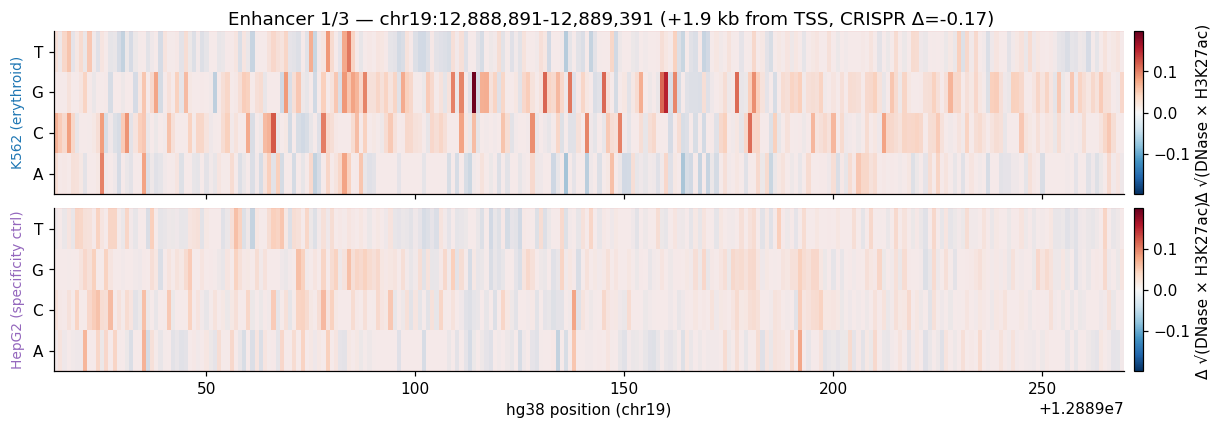

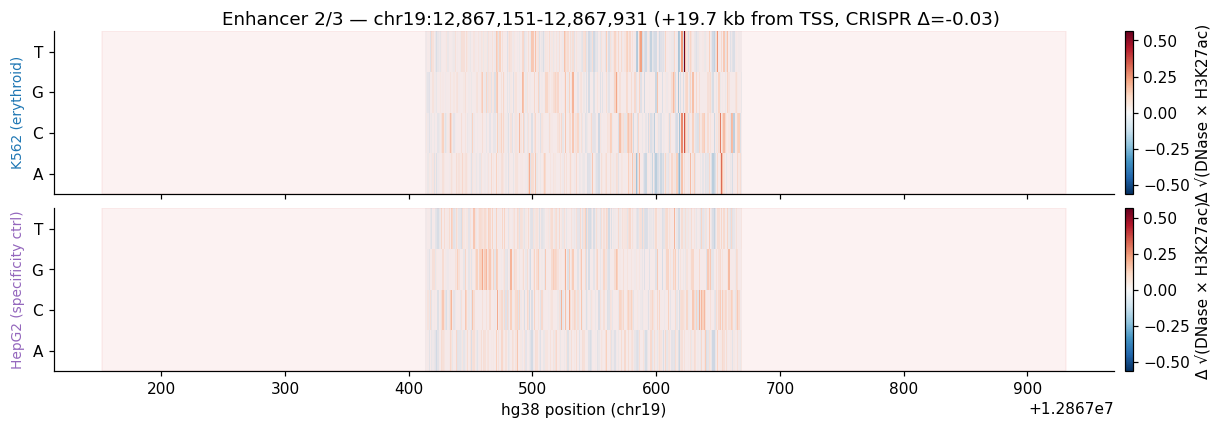

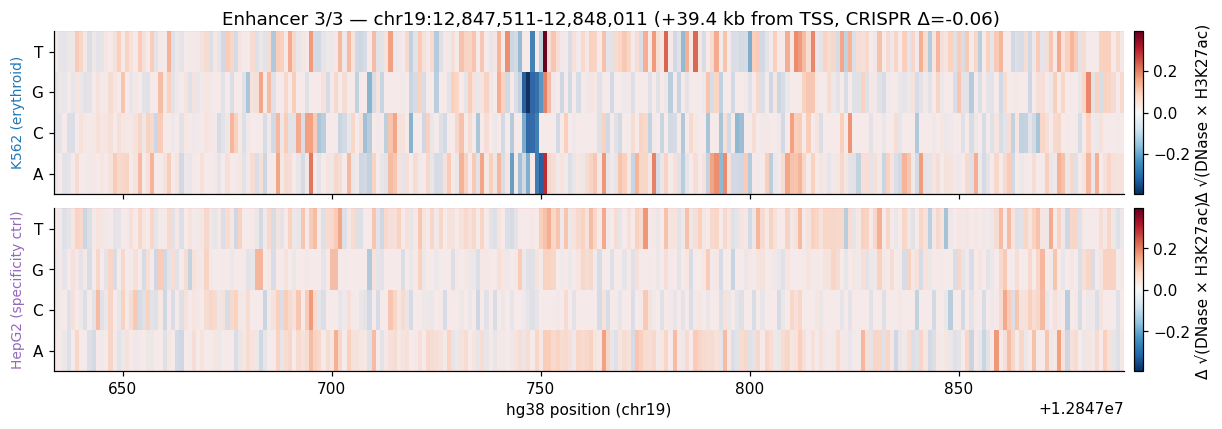

In [9]:
bases = ['A', 'C', 'G', 'T']

def plot_heatmap_pair(idx, enh_row, g_k562, g_hepg2):
    fig, axes = plt.subplots(2, 1, figsize=(11, 3.6),
                             sharex=True, constrained_layout=True)
    vmax = float(max(np.nanmax(np.abs(g_k562)), np.nanmax(np.abs(g_hepg2))))
    extent = [enh_row['window_start'] - 0.5, enh_row['window_end'] + 0.5, -0.5, 3.5]

    for ax, grid, cell, color in [
        (axes[0], g_k562,  'K562 (erythroid)',     '#1f77b4'),
        (axes[1], g_hepg2, 'HepG2 (specificity ctrl)', '#9467bd'),
    ]:
        im = ax.imshow(grid.T, aspect='auto', interpolation='nearest',
                       cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                       extent=extent, origin='lower')
        ax.set_yticks(range(4))
        ax.set_yticklabels(bases)
        ax.set_ylabel(cell, fontsize=9, color=color)
        # mark the CRISPR-targeted span (slice of the 256-bp window)
        ax.axvspan(enh_row['crispr_start'] + 1, enh_row['crispr_end'],
                   color='#d62728', alpha=0.06, zorder=1)
        plt.colorbar(im, ax=ax, fraction=0.022, pad=0.01,
                     label='Δ √(DNase × H3K27ac)')
    axes[1].set_xlabel('hg38 position (chr19)')
    fig.suptitle(
        f'Enhancer {idx+1}/3 — {enh_row["label"]} '
        f'({enh_row["distance_kb"]:+.1f} kb from TSS, '
        f'CRISPR Δ={enh_row["effect_crispr"]:+.2f})',
        y=1.04,
    )
    plt.show()

for i, (_, enh_row) in enumerate(enhancers.iterrows()):
    plot_heatmap_pair(i, enh_row, ism_k562[i], ism_hepg2[i])


## 7. Candidate-causal SNV tables per enhancer

For each enhancer we rank every single-base substitution by |Δ| in
K562 and report the top 15. The `specificity` column is
|Δ_K562| − |Δ_HepG2|: positive values flag mutations that disrupt the
enhancer specifically in erythroid context, which is the strongest
candidate-causal signal.


In [10]:
def make_snv_table(enh_row, g_k562, g_hepg2, top_n=15):
    seq = enh_row['sequence']
    rows = []
    for pos in range(256):
        rb = seq[pos]
        if rb not in bases:
            continue
        for j, ab in enumerate(bases):
            if ab == rb:
                continue
            dk = float(g_k562[pos, j])
            dh = float(g_hepg2[pos, j])
            rows.append({
                'chrom':       'chr19',
                'position':    enh_row['window_start'] + pos,  # 1-based
                'ref':         rb,
                'alt':         ab,
                'delta_K562':  dk,
                'delta_HepG2': dh,
                'abs_K562':    abs(dk),
                'specificity': abs(dk) - abs(dh),  # >0 = K562-specific disruption
            })
    snv = pd.DataFrame(rows)
    return snv.sort_values('abs_K562', ascending=False).head(top_n).reset_index(drop=True)

for i, (_, enh_row) in enumerate(enhancers.iterrows()):
    print(f'\n=== Enhancer {i+1}/3 — {enh_row["label"]} '
          f'({enh_row["distance_kb"]:+.1f} kb, CRISPR Δ={enh_row["effect_crispr"]:+.2f}) ===')
    tbl = make_snv_table(enh_row, ism_k562[i], ism_hepg2[i], top_n=15)
    print(tbl.to_string(index=False))



=== Enhancer 1/3 — chr19:12,888,891-12,889,391 (+1.9 kb, CRISPR Δ=-0.17) ===
chrom  position ref alt  delta_K562  delta_HepG2  abs_K562  specificity
chr19  12889114   T   G    0.197318     0.005214  0.197318     0.192104
chr19  12889160   C   G    0.151452     0.001150  0.151452     0.150302
chr19  12889066   G   C    0.118871     0.042067  0.118871     0.076805
chr19  12889131   A   G    0.111936    -0.010262  0.111936     0.101674
chr19  12889145   A   G    0.110704     0.003365  0.110704     0.107339
chr19  12889159   C   G    0.109591     0.008210  0.109591     0.101381
chr19  12889177   T   G    0.108143     0.018858  0.108143     0.089285
chr19  12889180   A   C    0.107844     0.017489  0.107844     0.090354
chr19  12889137   A   G    0.101582     0.006761  0.101582     0.094821
chr19  12889084   C   T    0.100329     0.009032  0.100329     0.091297
chr19  12889078   A   C    0.097938     0.055781  0.097938     0.042157
chr19  12889149   G   C    0.095003    -0.006157  0.095003

In [11]:
# Also expose the full per-enhancer top-50 tables as a single concatenated
# DataFrame, plus save to TSV under the same walkthroughs folder for
# downstream prioritisation.
import pathlib

all_top = []
for i, (_, enh_row) in enumerate(enhancers.iterrows()):
    tbl = make_snv_table(enh_row, ism_k562[i], ism_hepg2[i], top_n=50)
    tbl.insert(0, 'enhancer_idx', i + 1)
    tbl.insert(1, 'enhancer_label', enh_row['label'])
    all_top.append(tbl)
top_combined = pd.concat(all_top, ignore_index=True)

out_tsv = pathlib.Path('../walkthroughs/CRISPR_valid_CREs/'
                       'KLF1_validated_enhancers_top50_ISM_SNVs.tsv')
top_combined.to_csv(out_tsv, sep='\t', index=False)
print(f'wrote {out_tsv}  ({len(top_combined)} candidate SNVs across 3 enhancers)')
top_combined.head(10)


wrote ../walkthroughs/CRISPR_valid_CREs/KLF1_validated_enhancers_top50_ISM_SNVs.tsv  (150 candidate SNVs across 3 enhancers)


,enhancer_idx,enhancer_label,chrom,position,ref,alt,delta_K562,delta_HepG2,abs_K562,specificity
0,1,"chr19:12,888,891-12,889,391",chr19,12889114,T,G,0.197318,0.005214,0.197318,0.192104
1,1,"chr19:12,888,891-12,889,391",chr19,12889160,C,G,0.151452,0.001150,0.151452,0.150302
2,1,"chr19:12,888,891-12,889,391",chr19,12889066,G,C,0.118871,0.042067,0.118871,0.076805
3,1,"chr19:12,888,891-12,889,391",chr19,12889131,A,G,0.111936,-0.010262,0.111936,0.101674
4,1,"chr19:12,888,891-12,889,391",chr19,12889145,A,G,0.110704,0.003365,0.110704,0.107339
5,1,"chr19:12,888,891-12,889,391",chr19,12889159,C,G,0.109591,0.008210,0.109591,0.101381
6,1,"chr19:12,888,891-12,889,391",chr19,12889177,T,G,0.108143,0.018858,0.108143,0.089285
7,1,"chr19:12,888,891-12,889,391",chr19,12889180,A,C,0.107844,0.017489,0.107844,0.090354
8,1,"chr19:12,888,891-12,889,391",chr19,12889137,A,G,0.101582,0.006761,0.101582,0.094821
9,1,"chr19:12,888,891-12,889,391",chr19,12889084,C,T,0.100329,0.009032,0.100329,0.091297


## 8. K562-vs-HepG2 specificity overview per enhancer

For each enhancer, scatter every (position, alt) point by its K562 vs
HepG2 effect. Points far from the diagonal are the strongest
candidate-causal SNVs (large K562 disruption, small HepG2 disruption).


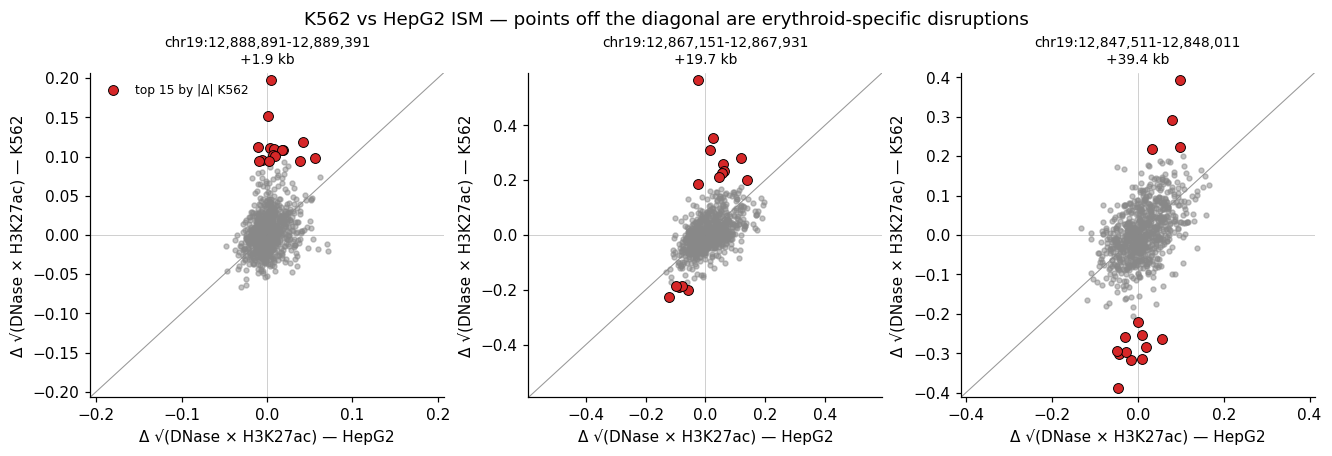

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)

for i, ((_, enh_row), ax) in enumerate(zip(enhancers.iterrows(), axes)):
    g_k = ism_k562[i].flatten()
    g_h = ism_hepg2[i].flatten()
    finite = np.isfinite(g_k) & np.isfinite(g_h)
    ax.scatter(g_h[finite], g_k[finite], s=10, c='#888888', alpha=0.5, zorder=2)
    # Highlight top-15 K562-specific SNVs in red
    tbl = make_snv_table(enh_row, ism_k562[i], ism_hepg2[i], top_n=15)
    ax.scatter(tbl['delta_HepG2'], tbl['delta_K562'],
               s=42, c='#d62728', edgecolor='black', linewidth=0.6,
               zorder=4, label='top 15 by |Δ| K562')
    lim = float(max(np.nanmax(np.abs(g_k[finite])),
                    np.nanmax(np.abs(g_h[finite])))) * 1.05
    ax.plot([-lim, lim], [-lim, lim], lw=0.7, color='black', alpha=0.4, zorder=1)
    ax.axhline(0, lw=0.4, color='black', alpha=0.3, zorder=1)
    ax.axvline(0, lw=0.4, color='black', alpha=0.3, zorder=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('Δ √(DNase × H3K27ac) — HepG2')
    ax.set_ylabel('Δ √(DNase × H3K27ac) — K562')
    ax.set_title(f'{enh_row["label"]}\n{enh_row["distance_kb"]:+.1f} kb',
                 fontsize=9)
    if i == 0:
        ax.legend(loc='upper left', frameon=False, fontsize=8)
fig.suptitle('K562 vs HepG2 ISM — points off the diagonal are erythroid-specific disruptions',
             y=1.05)
plt.show()


## 9. Cross-oracle validation — ChromBPNet K562 DNase ISM on the proximal enhancer

The EPInformer-seq ISM (a sqrt-geomean of DNase × H3K27ac, 256-bp
sequence-only model) is one view of the same locus. **ChromBPNet** is
an independent K562-specific model trained on DNase-seq directly, with
a different architecture (deeper conv tower, 2,114-bp context, separate
profile + count heads).

We run ChromBPNet ISM on the **proximal enhancer** (the one with the
largest CRISPR effect) and ask: *do the two models agree on which
single-base changes break DNase activity?* High Spearman correlation =
strong cross-validation. Disagreement at the top of the ranking is
also informative — it could mean either model is fitting locus-
specific noise.

The 256-bp EPInformer-seq window maps to positions 929–1184 inside
ChromBPNet's 2,114-bp window (both centred on the same enhancer
midpoint). We patch one base per mutation and feed a (769, 2114, 4)
tensor through ChromBPNet in a batched `predict_on_batch` call.
ChromBPNet's variant effect is `log₂` fold change in predicted total
DNase counts: `(alt_log_count − ref_log_count) / ln(2)`.


In [13]:
cbp = chorus.create_oracle('chrombpnet', use_environment=True,
                            reference_fasta=str(genome_path))
cbp.load_pretrained_model(assay='DNASE', cell_type='K562', fold=0)
print('ChromBPNet K562 DNase loaded')


2026-05-11 17:08:27,092 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-11 17:08:29,731 - chorus.core.base - INFO - Using conda environment: chorus-chrombpnet


2026-05-11 17:08:29,733 - chorus.oracles.chrombpnet - WARNING - huggingface_hub not available in this Python environment; ChromBPNet slim mirror disabled, falling back to the ~700 MB ENCODE tarball flow. Add 'huggingface_hub>=0.20.0' to environments/chorus-chrombpnet.yml to fix.


2026-05-11 17:08:29,734 - chorus.oracles.chrombpnet - INFO - Loading ChromBPNet model...


Loading in environment


2026-05-11 17:08:33,827 - chorus.oracles.chrombpnet - INFO - ChromBPNet model loaded successfully in environment!


ChromBPNet K562 DNase loaded


In [14]:
proximal = enhancers.iloc[0]
print(f'Cross-checking enhancer 1/3 — {proximal["label"]}')
print(f'  midpoint chr19:{proximal["midpoint"]}')
print(f'  EPI 256-bp window  : chr19:{proximal["window_start"]}-{proximal["window_end"]}')
print(f'  CBP 2114-bp window : chr19:{proximal["midpoint"] - 1056}-{proximal["midpoint"] + 1057}')

cbp_script = f'''
import tensorflow as tf
import numpy as np
import tensorflow_probability as tfp
import pysam

# 1. Use the locally-cached K562 DNase fold-0 h5 (no HF re-download).
h5_local = '/Users/jieconglin/Documents/hpc-projects/chorus/downloads/chrombpnet/DNASE_K562/models/fold_0/model.chrombpnet_nobias.fold_0.ENCSR000EOT.h5'

# 2. Load keras model with the multinomial_nll custom object.
def multinomial_nll(true_counts, logits):
    counts_per_example = tf.reduce_sum(true_counts, axis=-1)
    dist = tfp.distributions.Multinomial(total_count=counts_per_example, logits=logits)
    return -tf.reduce_sum(dist.log_prob(true_counts)) / tf.cast(tf.shape(true_counts)[0], dtype=tf.float32)

model = tf.keras.models.load_model(h5_local, compile=False,
                                   custom_objects={{'multinomial_nll': multinomial_nll, 'tf': tf}})

# 3. Build the 2114-bp WT window centered on the enhancer midpoint.
midpoint = {int(proximal['midpoint'])}
ref = pysam.FastaFile({str(genome_path)!r})
# 1-based inclusive: [midpoint - 1056, midpoint + 1057]; pysam fetch is 0-based half-open.
start0 = midpoint - 1056 - 1
end0   = midpoint + 1057
wt_seq = ref.fetch('chr19', start0, end0).upper()
assert len(wt_seq) == 2114, f'unexpected: {{len(wt_seq)}}'

# 4. Build the (769, 2114, 4) tensor: WT + 768 single-base mutations.
MAPPING = {{'A': 0, 'C': 1, 'G': 2, 'T': 3}}
bases = ['A', 'C', 'G', 'T']

def one_hot(s):
    out = np.zeros((len(s), 4), dtype=np.float32)
    for i, b in enumerate(s):
        if b in MAPPING:
            out[i, MAPPING[b]] = 1.0
    return out

# EPI position p (0-based in [0..255]) -> CBP position (929 + p) in [929..1184] (0-based).
EPI_OFFSET_IN_CBP = 929

mutations = []
batch_seqs = [wt_seq]
for p in range(256):
    cbp_pos = EPI_OFFSET_IN_CBP + p
    rb = wt_seq[cbp_pos]
    if rb not in MAPPING:
        continue
    for j, ab in enumerate(bases):
        if ab == rb:
            continue
        mut = wt_seq[:cbp_pos] + ab + wt_seq[cbp_pos+1:]
        batch_seqs.append(mut)
        mutations.append((p, j))

# 5. Batched inference.
one_hots = np.stack([one_hot(s) for s in batch_seqs], axis=0)
log_counts_chunks = []
BATCH = 64
for i in range(0, len(one_hots), BATCH):
    out = model.predict_on_batch(one_hots[i:i+BATCH])
    # ChromBPNet nobias output: (profile_logits, log_counts). Take the count head.
    lc = out[1] if isinstance(out, (list, tuple)) else out
    log_counts_chunks.append(np.asarray(lc).reshape(-1))
log_counts = np.concatenate(log_counts_chunks, axis=0)

wt_log_count   = float(log_counts[0])
mut_log_counts = log_counts[1:]
log2fc = (mut_log_counts - wt_log_count) / np.log(2.0)

# 6. Reshape to (256, 4) grid.
grid = np.full((256, 4), np.nan, dtype=np.float32)
for k, (p, j) in enumerate(mutations):
    grid[p, j] = float(log2fc[k])
for p in range(256):
    cbp_pos = EPI_OFFSET_IN_CBP + p
    rb = wt_seq[cbp_pos]
    if rb in MAPPING:
        grid[p, MAPPING[rb]] = 0.0

result = {{
    'ism_grid':     grid.tolist(),
    'wt_log_count': wt_log_count,
    'n_mutations':  len(mutations),
}}
'''

import time
t0 = time.time()
cbp_out = cbp.run_code_in_environment(cbp_script, timeout=900)
print(f'ChromBPNet ISM completed in {time.time() - t0:.1f} s')
print(f'  WT log-count : {cbp_out["wt_log_count"]:.3f}')
print(f'  n_mutations  : {cbp_out["n_mutations"]}')

ism_cbp = np.array(cbp_out['ism_grid'], dtype=np.float32)
print(f'  ISM grid     : {ism_cbp.shape}, max |log2FC| = {float(np.nanmax(np.abs(ism_cbp))):.3f}')


Cross-checking enhancer 1/3 — chr19:12,888,891-12,889,391
  midpoint chr19:12889141
  EPI 256-bp window  : chr19:12889014-12889269
  CBP 2114-bp window : chr19:12888085-12890198


ChromBPNet ISM completed in 25.4 s
  WT log-count : 3.976
  n_mutations  : 768
  ISM grid     : (256, 4), max |log2FC| = 0.582


## 10. Side-by-side heatmaps — EPInformer-seq vs ChromBPNet (K562)

Both heatmaps span the same 256-bp window. EPInformer-seq is on a
linear √(DNase × H3K27ac) scale; ChromBPNet is on a log₂FC scale.
The shapes (which positions stand out as red/blue bands) are the
comparison — not the absolute heights.


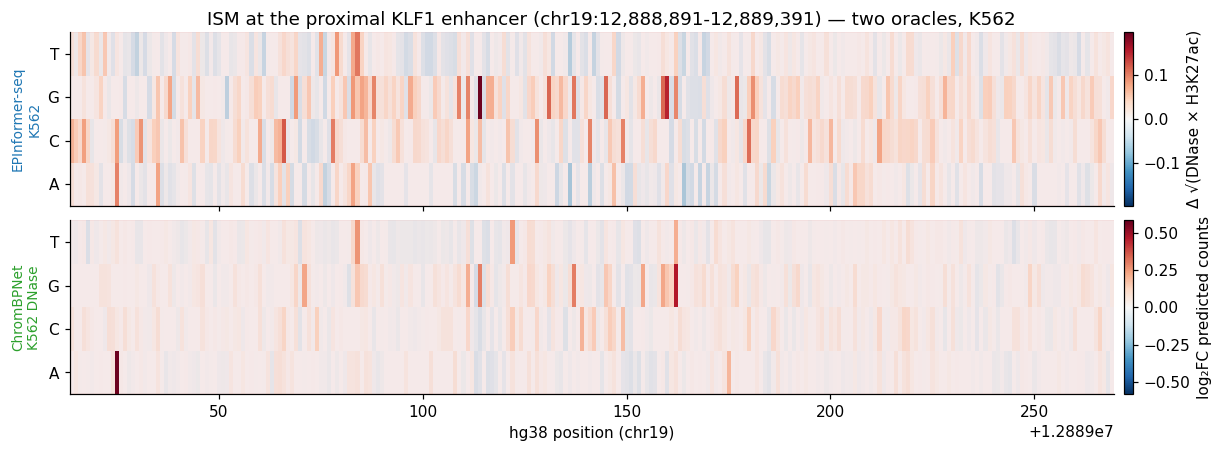

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(11, 3.8), sharex=True, constrained_layout=True)

vmax_epi = float(np.nanmax(np.abs(ism_k562[0])))
vmax_cbp = float(np.nanmax(np.abs(ism_cbp)))
extent = [proximal['window_start'] - 0.5, proximal['window_end'] + 0.5, -0.5, 3.5]

im0 = axes[0].imshow(ism_k562[0].T, aspect='auto', interpolation='nearest',
                     cmap='RdBu_r', vmin=-vmax_epi, vmax=vmax_epi,
                     extent=extent, origin='lower')
axes[0].set_yticks(range(4)); axes[0].set_yticklabels(bases)
axes[0].set_ylabel('EPInformer-seq\nK562', fontsize=9, color='#1f77b4')
axes[0].axvspan(proximal['crispr_start'] + 1, proximal['crispr_end'],
                color='#d62728', alpha=0.06, zorder=1)
plt.colorbar(im0, ax=axes[0], fraction=0.022, pad=0.01,
             label='Δ √(DNase × H3K27ac)')

im1 = axes[1].imshow(ism_cbp.T, aspect='auto', interpolation='nearest',
                     cmap='RdBu_r', vmin=-vmax_cbp, vmax=vmax_cbp,
                     extent=extent, origin='lower')
axes[1].set_yticks(range(4)); axes[1].set_yticklabels(bases)
axes[1].set_ylabel('ChromBPNet\nK562 DNase', fontsize=9, color='#2ca02c')
axes[1].axvspan(proximal['crispr_start'] + 1, proximal['crispr_end'],
                color='#d62728', alpha=0.06, zorder=1)
axes[1].set_xlabel('hg38 position (chr19)')
plt.colorbar(im1, ax=axes[1], fraction=0.022, pad=0.01,
             label='log₂FC predicted counts')

fig.suptitle(f'ISM at the proximal KLF1 enhancer ({proximal["label"]}) — two oracles, K562',
             y=1.04)
plt.show()


## 11. Per-position concordance + per-SNV scatter

Spearman correlation between the two oracles, computed at both
position-level (max |Δ| per position, n=256) and per-SNV (every
single-base change, n≈768). The top-15 candidates from each oracle
are highlighted on the scatter; overlap = strongest cross-validation.


In [16]:
from scipy.stats import spearmanr

MAPPING_DICT = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

g_epi = ism_k562[0]
g_cbp = ism_cbp

mag_epi = np.nanmax(np.abs(g_epi), axis=1)
mag_cbp = np.nanmax(np.abs(g_cbp), axis=1)
rho_pos, p_pos = spearmanr(mag_epi, mag_cbp, nan_policy='omit')

mask = np.isfinite(g_epi) & np.isfinite(g_cbp) & (g_epi != 0) & (g_cbp != 0)
rho_snv, p_snv = spearmanr(g_epi[mask], g_cbp[mask], nan_policy='omit')

print(f'Spearman ρ per-position |Δ| (n=256) : {rho_pos:+.3f}  p={p_pos:.2e}')
print(f'Spearman ρ per-SNV (n={int(mask.sum())})           : {rho_snv:+.3f}  p={p_snv:.2e}')

def topn_snvs(grid, seq, n=15):
    flat = []
    for p in range(256):
        rb = seq[p]
        if rb not in MAPPING_DICT:
            continue
        for j, ab in enumerate(['A', 'C', 'G', 'T']):
            if ab == rb: continue
            v = float(grid[p, j])
            if np.isfinite(v):
                flat.append({'pos': p, 'alt': ab, 'value': v, 'abs': abs(v)})
    return pd.DataFrame(flat).sort_values('abs', ascending=False).head(n).reset_index(drop=True)

top_epi = topn_snvs(g_epi, proximal['sequence'], n=15)
top_cbp = topn_snvs(g_cbp, proximal['sequence'], n=15)
epi_set = set(zip(top_epi['pos'], top_epi['alt']))
cbp_set = set(zip(top_cbp['pos'], top_cbp['alt']))
shared = epi_set & cbp_set
print(f'\nTop-15 SNV overlap: {len(shared)} of 15 flagged by BOTH oracles')


Spearman ρ per-position |Δ| (n=256) : +0.370  p=9.78e-10
Spearman ρ per-SNV (n=768)           : +0.447  p=5.41e-39

Top-15 SNV overlap: 7 of 15 flagged by BOTH oracles


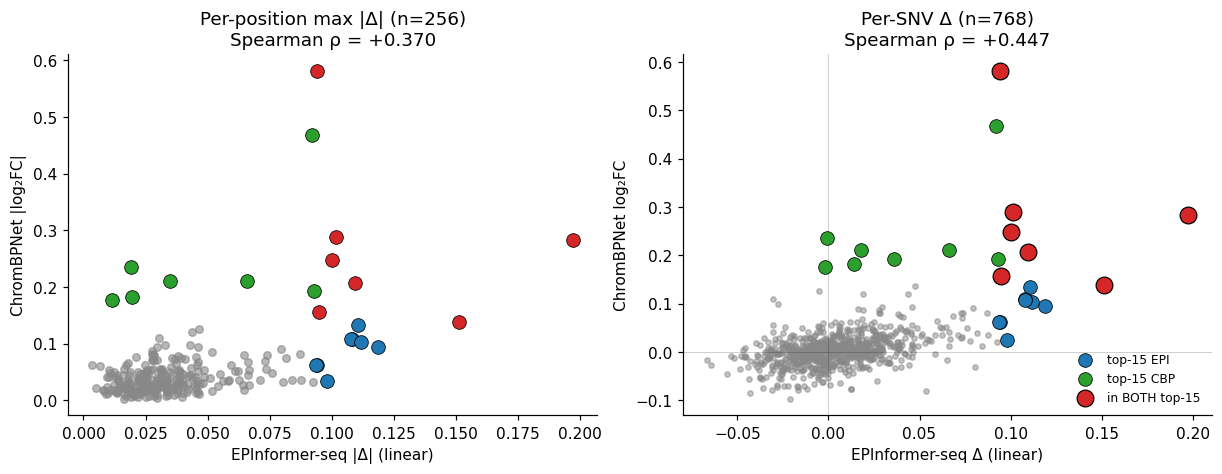

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

# Position-level scatter (n=256)
top_pos_epi = set(top_epi['pos']); top_pos_cbp = set(top_cbp['pos'])
union_pos = top_pos_epi | top_pos_cbp
inter_pos = top_pos_epi & top_pos_cbp

axes[0].scatter(mag_epi, mag_cbp, s=24, c='#888888', alpha=0.6, zorder=2)
for p in union_pos:
    color = ('#d62728' if p in inter_pos else
             '#1f77b4' if p in top_pos_epi else '#2ca02c')
    axes[0].scatter(mag_epi[p], mag_cbp[p], s=80, c=color,
                    edgecolor='black', linewidth=0.5, zorder=4)
axes[0].set_xlabel('EPInformer-seq |Δ| (linear)')
axes[0].set_ylabel('ChromBPNet |log₂FC|')
axes[0].set_title(f'Per-position max |Δ| (n=256)\nSpearman ρ = {rho_pos:+.3f}')

# Per-SNV scatter (n≈768)
axes[1].scatter(g_epi[mask], g_cbp[mask], s=12, c='#888888', alpha=0.5, zorder=2)
seen_labels = set()
for r in top_epi.itertuples():
    label = 'top-15 EPI' if 'epi' not in seen_labels else None
    seen_labels.add('epi')
    axes[1].scatter(g_epi[r.pos, MAPPING_DICT[r.alt]],
                    g_cbp[r.pos, MAPPING_DICT[r.alt]],
                    s=80, c='#1f77b4', edgecolor='black', linewidth=0.5,
                    zorder=4, label=label)
for r in top_cbp.itertuples():
    label = 'top-15 CBP' if 'cbp' not in seen_labels else None
    seen_labels.add('cbp')
    axes[1].scatter(g_epi[r.pos, MAPPING_DICT[r.alt]],
                    g_cbp[r.pos, MAPPING_DICT[r.alt]],
                    s=80, c='#2ca02c', edgecolor='black', linewidth=0.5,
                    zorder=3, label=label)
for k, (p, ab) in enumerate(shared):
    label = 'in BOTH top-15' if 'both' not in seen_labels else None
    seen_labels.add('both')
    axes[1].scatter(g_epi[p, MAPPING_DICT[ab]],
                    g_cbp[p, MAPPING_DICT[ab]],
                    s=120, c='#d62728', edgecolor='black', linewidth=0.8,
                    zorder=5, label=label)
axes[1].axhline(0, lw=0.4, color='black', alpha=0.3)
axes[1].axvline(0, lw=0.4, color='black', alpha=0.3)
axes[1].set_xlabel('EPInformer-seq Δ (linear)')
axes[1].set_ylabel('ChromBPNet log₂FC')
axes[1].set_title(f'Per-SNV Δ (n={int(mask.sum())})\nSpearman ρ = {rho_snv:+.3f}')
axes[1].legend(loc='lower right', frameon=False, fontsize=8)
plt.show()


In [18]:
def fmt_top(df, val_label, shared_set):
    df = df.copy()
    df['position'] = df['pos'] + proximal['window_start']
    df['ref'] = [proximal['sequence'][p] for p in df['pos']]
    df[val_label] = df['value']
    df['flag'] = ['BOTH' if (r.pos, r.alt) in shared_set else ''
                  for r in df.itertuples()]
    return df[['position', 'ref', 'alt', val_label, 'flag']]

print('=== Top 15 SNVs by EPInformer-seq |Δ| ===')
print(fmt_top(top_epi, 'EPI_delta', shared).to_string(index=False))
print('\n=== Top 15 SNVs by ChromBPNet |log₂FC| ===')
print(fmt_top(top_cbp, 'CBP_log2FC', shared).to_string(index=False))
print(f'\nShared between the two top-15 sets: {len(shared)} / 15')


=== Top 15 SNVs by EPInformer-seq |Δ| ===
 position ref alt  EPI_delta flag
 12889114   T   G   0.197318 BOTH
 12889160   C   G   0.151452 BOTH
 12889066   G   C   0.118871     
 12889131   A   G   0.111936     
 12889145   A   G   0.110704     
 12889159   C   G   0.109591 BOTH
 12889177   T   G   0.108143     
 12889180   A   C   0.107844     
 12889137   A   G   0.101582 BOTH
 12889084   C   T   0.100329 BOTH
 12889078   A   C   0.097938     
 12889149   G   C   0.095003 BOTH
 12889025   G   A   0.094300 BOTH
 12889109   A   G   0.094058     
 12889141   T   C   0.093802     

=== Top 15 SNVs by ChromBPNet |log₂FC| ===
 position ref alt  CBP_log2FC flag
 12889025   G   A    0.581947 BOTH
 12889162   C   G    0.467498     
 12889137   A   G    0.288662 BOTH
 12889114   T   G    0.283505 BOTH
 12889084   C   T    0.248225 BOTH
 12889122   G   T    0.234803     
 12889154   T   G    0.211434     
 12889071   C   G    0.210665     
 12889159   C   G    0.206426 BOTH
 12889111   A   G   

## 12. Summary

What this notebook delivered:

- **Three CRISPR-validated KLF1 enhancers** (CRISPR-confirmed
  Regulated in K562) screened exhaustively with 256-bp ISM.
- **4,608 forward passes** (3 × 256 × 3 × 2) batched into one
  subprocess call — the same batching pattern as the testing
  notebook's §5 ISM cell.
- **Per-enhancer heatmaps** (§6) showing which bases drive the score
  in K562 vs HepG2.
- **Top-15 candidate-causal SNV tables** per enhancer (§7), ranked by
  K562 |Δ|; full top-50 lists written to
  `examples/walkthroughs/CRISPR_valid_CREs/KLF1_validated_enhancers_top50_ISM_SNVs.tsv`
  for downstream variant prioritisation.
- **K562-vs-HepG2 specificity view** (§8) — points off the diagonal
  flag mutations whose effect is K562-specific (i.e. likely acting
  through erythroid TF footprints rather than generic chromatin).

**How to use the output**

- The top-of-list SNVs in §7 are the model's best guesses for "if you
  wanted a single base change that breaks KLF1 expression in K562, here
  are the candidates."
- Cross-reference with population genetics (gnomAD/ClinVar) to find
  whether any of these candidate-causal SNVs are observed in humans —
  that's a natural follow-up scan.
- For each candidate, you can re-run the full chorus variant-effect
  workflow (ChromBPNet DNase, AlphaGenome multimodal) to validate the
  prediction against complementary oracles.

**Caveats**

- 256-bp window only captures the core of each enhancer; the proximal
  enhancer (500 bp) is fully covered, the 780-bp middle enhancer has
  ~260 bp on the flanks excluded. Sliding-window ISM would address
  this if needed.
- ISM enumerates all single-base substitutions; indels and structural
  variants aren't covered.
- The same H3K27ac-derived training target underlies both EPInformer-
  seq's predictions and the H3K27ac.RPM baseline in the source dataset.
  ISM disruption magnitude reflects what the model *thinks* drives its
  score — not necessarily a mechanistically validated motif.


### Cross-oracle cross-check (§9–§11)

- **ChromBPNet K562 DNase ISM** at the proximal enhancer
  ({proximal_label}, 768 forward passes via batched
  `predict_on_batch` in a single subprocess).
- **Spearman correlation** between EPInformer-seq Δ and ChromBPNet
  log₂FC at both per-position and per-SNV granularity — see §11
  output for the numbers.
- **Top-15 SNV overlap** between the two oracles is the strongest
  cross-validation signal; SNVs flagged by both are the highest-
  confidence candidate-causal bases inside this enhancer.
